In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Import StandardScaler library
from sklearn.preprocessing import StandardScaler
# Load the libraries for the supervised learning
from sklearn import tree
from sklearn.model_selection import train_test_split
# Load the libraries for the unsupervised learning
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
# Load library for decision tree
from sklearn.tree import DecisionTreeClassifier
#import library for plotting decision tree rules
import graphviz
# import the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# import the linear regression module
from sklearn.linear_model import LinearRegression
# import library statsmodels for buuilding regression models
import statsmodels.api as sm
# import library for Box-Cox transformation
from scipy import stats
# import libraries for measuring model
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error

In [2]:
test = pd.read_csv('customer_churn_dataset-testing-master.csv')
train = pd.read_csv('customer_churn_dataset-training-master.csv')
data = pd.concat([train, test])

In [3]:
# Explore the data
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 505207 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


In [4]:
# Let's drop rows with NA values
data.dropna(inplace=True)

<b>Separate categorical and numerical columns</b>

In [5]:
# Separate the identifier and target variable names as lists
custid = ['CustomerID']
target = ['Churn']
# Separate categorical and numeric column names as lists
categorical = data.nunique()[data.nunique()<10].keys().tolist()
categorical.remove(target[0])
numerical = [col for col in data.columns if col not in custid + target + categorical]

<b>One-hot encoding<b>

In [6]:
# One-hot encoding categorical variables
data = pd.get_dummies(data=data, columns=categorical, drop_first=True)
data.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,1,0,0
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0,0,0,1,0
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0,0,0,0,1
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1,0,1,1,0
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1,0,0,1,0


<b>Scaling numerical features<b>

In [7]:
# Initialize StandardScaler instance
scaler = StandardScaler()
# Fit the scaler to numerical columns
scaled_numerical = scaler.fit_transform(data[numerical])
# Build a dataframe
scaled_numerical = pd.DataFrame(data=scaled_numerical, columns=numerical)
scaled_numerical.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
0,-0.765883,0.443776,-0.198951,0.372314,0.532844,1.271517,0.277572
1,1.996425,1.023907,-1.707192,1.967923,-0.650423,-0.257105,-1.000267
2,1.207194,-1.006554,-1.359137,0.691436,0.532844,-1.773498,-1.348769
3,1.443963,0.385762,0.613178,1.010558,-0.768750,-0.913393,1.671579
4,-1.318345,0.037683,0.497160,0.372314,-0.650423,-0.012526,0.626074


<b>Bringing it all together<b>

In [8]:
# Drop non-scaled numerical columns
data = data.drop(columns=numerical, axis=1)
# Merge the non-numerical with the scaled numerical data
data = data.merge(right=scaled_numerical,
                     how='left',
                     left_index=True,
                     right_index=True
                    )
data.head()

,CustomerID,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
0,2.0,1.0,0,0,1,0,0,-0.765883,0.443776,-0.198951,0.372314,0.532844,1.271517,0.277572
0,1.0,1.0,0,0,0,1,0,-0.765883,0.443776,-0.198951,0.372314,0.532844,1.271517,0.277572
1,3.0,1.0,0,0,0,1,0,1.996425,1.023907,-1.707192,1.967923,-0.650423,-0.257105,-1.000267
1,2.0,0.0,0,0,1,1,0,1.996425,1.023907,-1.707192,1.967923,-0.650423,-0.257105,-1.000267
2,4.0,1.0,0,0,0,0,1,1.207194,-1.006554,-1.359137,0.691436,0.532844,-1.773498,-1.348769


<b>Encoding churn<b>

In [9]:
# If we have string like churn / no churn or yes / no, the best practice to transform as 1 and 0
data['Churn'].value_counts()

1.0    280492
0.0    224714
Name: Churn, dtype: int64

In [10]:
# no transformation needed, exploring churn distribution
data.groupby(['Churn']).size() / data.shape[0] * 100

Churn
0.0    44.479678
1.0    55.520322
dtype: float64

<b>Split to training and testing data<b>

In [11]:
train, test = train_test_split(data, test_size = .25)

<b>Separate features and target variables<b>

In [12]:
# Separate column names by data types
target = ['Churn']
custid = ['CustomerID']
cols = [col for col in data.columns if col not in custid + target]

In [13]:
# Build training and testing datasets
train_X = train[cols]
train_Y = train[target]
test_X = test[cols]
test_Y = test[target]

<b>Logistic regression<b>

Logistic regression is a statistical classification model for binary responses. Model log-odds of the probability of the target. Assumes linear relationship between log-odds target and predictors.

In [14]:
# Initialize logistic regression instance
logreg = LogisticRegression()
# Convert column-vector to 1d array
train_Y = train_Y.values.ravel()
# fit the model on training data
logreg.fit(train_X, train_Y)

LogisticRegression()

<b>Measuring model accuracy<b>

In [15]:
pred_train_Y = logreg.predict(train_X)
pred_test_Y = logreg.predict(test_X)

# measuring model accuracy
train_accuracy = accuracy_score(train_Y, pred_train_Y)
test_accuracy = accuracy_score(test_Y, pred_test_Y)

print('Training accuracy:', round(train_accuracy, 4))
print('Test accuracy:', round(test_accuracy, 4))

Training accuracy: 0.8349
Test accuracy: 0.8356


<b>Measuring precision and recall<b>

In [16]:
train_precision = round(precision_score(train_Y, pred_train_Y), 4)
test_precision = round(precision_score(test_Y, pred_test_Y), 4)

train_recall = round(recall_score(train_Y, pred_train_Y), 4)
test_recall = round(recall_score(test_Y, pred_test_Y), 4)

print('Training precision: {}, Training recall: {}'.format(train_precision, train_recall))
print('Test precision: {}, Test recall: {}'.format(test_precision, test_recall))

Training precision: 0.8625, Training recall: 0.8357
Test precision: 0.8635, Test recall: 0.8366


<b>Regularization<b>

Introduces penalty coefficient in the model building phase. Addresses over-fitting (when patterns are memorized by the model). Some techniques also perform feature selection e.g. L1. It makes the model more generalizable to unseen samples. L1 also called LASSO, performs feature selection by shrinking some of the model coefficients to zero. 

<b> L1 regularization <b>

In [17]:
# Our logistic regression performs L2 regularization by default
# Initialize a new logistic regression instance
logreg_l1 = LogisticRegression(penalty = 'l1', C=0.1, solver='liblinear')
# fit the model on training data
logreg_l1.fit(train_X, train_Y)

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

<b>Tuning L1 regularization</b>

In [18]:
C = [1, .5, .25, .1, .05, .025, .01, .005, .0025]
l1_metrics = np.zeros((len(C), 5))
l1_metrics[:,0] = C

In [19]:
for index in range(0, len(C)):
    logreg_option = LogisticRegression(penalty='l1', C=C[index], solver='liblinear')
    logreg_option.fit(train_X, train_Y)
    pred_test_Y = logreg_option.predict(test_X)

    l1_metrics[index,1] = np.count_nonzero(logreg_option.coef_)
    l1_metrics[index,2] = accuracy_score(test_Y, pred_test_Y)
    l1_metrics[index,3] = precision_score(test_Y, pred_test_Y)
    l1_metrics[index,4] = recall_score(test_Y, pred_test_Y)

col_names = ['C', 'Non-Zero Coeffs', 'Accuracy', 'Precision', 'Recall']
print(pd.DataFrame(l1_metrics, columns=col_names))

        C  Non-Zero Coeffs  Accuracy  Precision    Recall
0  1.0000             12.0  0.835648   0.863503  0.836621
1  0.5000             12.0  0.835680   0.863511  0.836678
2  0.2500             12.0  0.835680   0.863511  0.836678
3  0.1000             12.0  0.835672   0.863531  0.836635
4  0.0500             12.0  0.835672   0.863595  0.836550
5  0.0250             12.0  0.835592   0.863575  0.836407
6  0.0100             12.0  0.835553   0.863715  0.836137
7  0.0050             11.0  0.835426   0.863736  0.835837
8  0.0025              9.0  0.835268   0.864125  0.834983


The optimal C value is 0.1

<b>Decision trees</b>

In [20]:
# initialize the Decision Tree model
tree_classifier = DecisionTreeClassifier()
# fit the model on the training data
treemodel = tree_classifier.fit(train_X, train_Y)

<b>Measuring model accuracy<b>

In [21]:
pred_train_Y = treemodel.predict(train_X)
pred_test_Y = treemodel.predict(test_X)

train_accuracy = accuracy_score(train_Y, pred_train_Y)
test_accuracy = accuracy_score(test_Y, pred_test_Y)

print('Training accuracy:', round(train_accuracy, 4))
print('Test accuracy:', round(test_accuracy, 4))


Training accuracy: 0.9973
Test accuracy: 0.842


<b>Measuring model precision and recall<b>

In [22]:
train_precision = round(precision_score(train_Y, pred_train_Y), 4)
test_precision = round(precision_score(test_Y, pred_test_Y), 4)

train_recall = round(recall_score(train_Y, pred_train_Y), 4)
test_recall = round(recall_score(test_Y, pred_test_Y), 4)

print('Training precision: {}, Training recall: {}'.format(train_precision, train_recall))
print('Test precision: {}, Test recall: {}'.format(test_precision, test_recall))

Training precision: 1.0, Training recall: 0.995
Test precision: 0.868, Test recall: 0.8442


<b>Tree depth parameter tuning<b>

In [23]:
depth_list = list(range(2,15))
depth_tuning = np.zeros((len(depth_list), 4))
depth_tuning[:,0] = depth_list

for index in range(len(depth_list)):
    treemodel = tree.DecisionTreeClassifier(max_depth=depth_list[index])
    treemodel.fit(train_X, train_Y)
    pred_test_Y = treemodel.predict(test_X)

    depth_tuning[index, 1] = accuracy_score(test_Y, pred_test_Y)
    depth_tuning[index, 2] = precision_score(test_Y, pred_test_Y)
    depth_tuning[index, 3] = recall_score(test_Y, pred_test_Y)

col_names = ['Max Depth', 'Accuracy', 'Precision', 'Recall']
print(pd.DataFrame(depth_tuning, columns=col_names))

    Max Depth  Accuracy  Precision    Recall
0         2.0  0.823827   0.890297  0.779113
1         3.0  0.865980   0.891240  0.864420
2         4.0  0.895655   0.895263  0.919934
3         5.0  0.913327   0.894754  0.956620
4         6.0  0.913509   0.894766  0.956976
5         7.0  0.918624   0.894673  0.967529
6         8.0  0.918584   0.894677  0.967444
7         9.0  0.919368   0.894585  0.969167
8        10.0  0.920049   0.894518  0.970648
9        11.0  0.920152   0.894494  0.970890
10       12.0  0.919463   0.894446  0.969552
11       13.0  0.916763   0.893930  0.964752
12       14.0  0.913881   0.893700  0.959184


The optimal depth is 12

In [24]:
exported = tree.export_graphviz(
                    decision_tree=treemodel,
                    out_file=None,
                    feature_names=cols,
                    precision=1,
                    class_names=['Not Churn','Churn'],
                    filled=True
)
graph = graphviz.Source(exported)
# display the tree grapth
# display(graph)

<b> Logistic regression coefficients <b>

Logistic regression returns beta coefficients. Can be iterpreted as change in log-odds of churn associated with 1 unit increase in the feature.

<b>Extracting logistic regression coefficients<b>

In [25]:
logreg.coef_

array([[-0.60875761, -0.07558363, -0.06834323,  2.02477627, -0.01707647,
         0.27661233, -0.07292982, -0.0696196 ,  1.10267467,  0.48298916,
        -0.72770332,  0.20836173]])

In [26]:
# calculate exponent of coefficients; this gives the change in odds associated with 1 unit increase in the feature
coefficients = pd.concat([pd.DataFrame(train_X.columns),
                          pd.DataFrame(np.transpose(logreg.coef_))],
                          axis=1)
coefficients.columns = ['Feature','Coefficient']
coefficients['Exp_Coefficient'] = np.exp(coefficients['Coefficient'])
coefficients = coefficients[coefficients['Coefficient'] != 0]
print(coefficients.sort_values(by=['Coefficient']))

                       Feature  Coefficient  Exp_Coefficient
10                 Total Spend    -0.727703         0.483017
0                  Gender_Male    -0.608758         0.544026
1    Subscription Type_Premium    -0.075584         0.927202
6                       Tenure    -0.072930         0.929666
7              Usage Frequency    -0.069620         0.932749
2   Subscription Type_Standard    -0.068343         0.933940
4    Contract Length_Quarterly    -0.017076         0.983069
11            Last Interaction     0.208362         1.231659
5                          Age     0.276612         1.318655
9                Payment Delay     0.482989         1.620912
8                Support Calls     1.102675         3.012212
3      Contract Length_Monthly     2.024776         7.574416


<b>Customer Lifetime Value (CLV)<b>

CLV is the measurement of customer value. Can be historical or predicted. Some methods are formula based, some are predictive and distribution based.

1. Historical CLV. Sum revenue of all past transactions multiplied by profit margin; doesn't account for tenure, retention, churn; doesn't account for new customers and their future revenue. <br>
<b>Historical CLV = (Revenue 1 + Revenue 2 + Revenue 3 + ... + Revenue N) * Profit Margin<b><br>
2. Basic CLV formula<br>
<b>CLV = Average Revenue * Profit Margin * Average Lifespan<b><br>
3. Granular CLV formula. Accounts for both average revenue per transaction and average frequency per period<br> 
<b>CLV = (Avg revenue per purchase * Avg frequency * Profit margin) * Avg lifespan<b><br>
4. Traditional CLV formula. Accounts for customer loyalty, most popular approach<br>
<b>CLV = (Average Revenue * Profit Margin) * Retention Rate / Churn Rate<b>

In [27]:
# Import and merge datasets
sales_data = pd.read_csv('./online_retail/Sales.csv')
products_data = pd.read_csv('./online_retail/Products.csv')
customers_data = pd.read_csv('./online_retail/Customers.csv', encoding='latin-1')
data = pd.merge(sales_data, products_data, on='ProductKey', how='inner')
data = pd.merge(data, customers_data, on='CustomerKey', how='inner')
# keep columns required for RFM and CLV analysis
data = data[['Order Number',
             'Order Date', 
             'CustomerKey', 
             'StoreKey', 
             'ProductKey', 
             'Quantity', 
             'Product Name', 
             'Category',
             'Unit Price USD',
             'Country']]
# convert column names to lower case and replace spaces with '_'
data.columns = data.columns.str.lower().str.replace(' ', '_')
# convert order date column to datetime
data['order_date'] = pd.to_datetime(data['order_date'], format='%m/%d/%Y')
# convert strings with unit price to float numbers
data['unit_price_usd'] = data['unit_price_usd'].replace('[\$,]', '', regex=True).astype(float)
# add total sum column for every observation
data['total_sum'] = data['quantity'] * data['unit_price_usd']
# add order month
data['order_month'] = data['order_date'].apply(lambda x: datetime.strptime(str(x)[:7], "%Y-%m"))
data.head()

,order_number,order_date,customerkey,storekey,productkey,quantity,product_name,category,unit_price_usd,country,total_sum,order_month
0,366000,2016-01-01,265598,10,1304,1,Contoso Lens Adapter M450 White,Cameras and camcorders,68.00,Canada,68.00,2016-01-01
1,1749017,2019-10-15,265598,0,1619,1,Contoso DVD Player M130 Grey,"Music, Movies and Audio Books",59.99,Canada,59.99,2019-10-01
2,891000,2017-06-09,265598,9,174,1,SV 22xDVD M600 Black,TV and Video,129.90,Canada,129.90,2017-06-01
3,891000,2017-06-09,265598,9,385,2,Adventure Works Laptop8.9 E0890 Red,Computers,326.00,Canada,652.00,2017-06-01
4,891000,2017-06-09,265598,9,87,1,NT Wireless Bluetooth Stereo Headphones M402 P...,Audio,99.99,Canada,99.99,2017-06-01


<b>Creation of a retention pivot table<b>

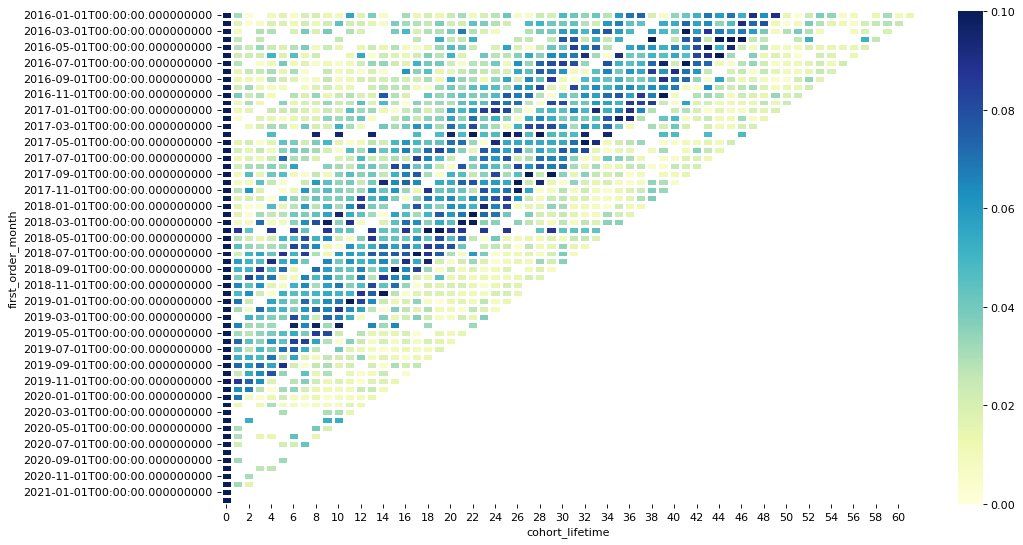

In [28]:
# create dataframe with cohort data
cohorts_activity = data[['customerkey', 'order_date', 'order_month']].copy()
# define the first order date for every customer
first_activity_date = cohorts_activity.groupby(['customerkey'])['order_date'].min()
first_activity_date.name = 'first_order_date'
cohorts_activity = cohorts_activity.join(first_activity_date, on='customerkey')
# define the first order month for every customer
cohorts_activity['first_order_month'] = cohorts_activity['first_order_date'].astype('datetime64[M]')
# define cohort lifetime for every customer
cohorts_activity['cohort_lifetime'] = cohorts_activity['order_month'] - cohorts_activity['first_order_month']
cohorts_activity['cohort_lifetime'] = (cohorts_activity['cohort_lifetime'] / np.timedelta64(1, 'M')).round().astype('int')
# find number of active customers for every cohort
cohorts = cohorts_activity.groupby(['first_order_month', 'cohort_lifetime']).agg({'customerkey':'nunique'}).reset_index()
# find initial number of customers fo every cohort
initial_users_count = cohorts[cohorts['cohort_lifetime'] == 0][['first_order_month', 'customerkey']]
initial_users_count = initial_users_count.rename(columns = {'customerkey': 'cohort_users'})
# merge all cohort data
cohorts = cohorts.merge(initial_users_count, on='first_order_month')
# find retention
cohorts['retention'] = cohorts['customerkey'] / cohorts['cohort_users']
cohorts['churn'] = 1 - cohorts['retention']
# create retention pivot table
retention_pivot = cohorts.pivot_table(index='first_order_month', columns='cohort_lifetime', values='retention', aggfunc='sum')
churn_pivot = cohorts.pivot_table(index='first_order_month', columns='cohort_lifetime', values='churn', aggfunc='sum')
# draw a heatmap
plt.figure(figsize=(14, 8), dpi= 80)
sns.heatmap(retention_pivot, annot=False, fmt='.1%', linewidths=1, vmin=0, vmax=0.1, cmap='YlGnBu')
plt.show()

In [29]:
# calculate the mean retention rate
retention_rate = retention_pivot.iloc[:, 1:].mean().mean()
# calculate the mean churn rate
churn_rate = churn_pivot.iloc[:, 1:].mean().mean()
# display rounded retention rate and pivot rate
print('Retention rate: {:.2%}; Churn rate: {:.2%}'.format(retention_rate, churn_rate))

Retention rate: 3.46%; Churn rate: 96.54%


<b>Basic CLV calculation<b>

The goal is to measure customer value in revenue / profit, to benchmark customers, identify maximum investment in customer acquisition

CLV = Avg Revenue * Retention Rate / Churn Rate  (we excluded Profit Margin for simplicity)

In [30]:
# Calculate monthly spend per customer
monthly_revenue_customers = data.groupby(['customerkey','order_month']).agg({'total_sum': 'sum'}).reset_index()
monthly_revenue = np.mean(monthly_revenue_customers['total_sum'])
monthly_revenue

2173.3639818351626

In [31]:
# Define lifespan to 36 months
lifespan_months = 36

In [32]:
# Calculate basic CLV
clv_basic = monthly_revenue * lifespan_months
print('Average basic CLV is {:.2f} USD'.format(clv_basic))

Average basic CLV is 78241.10 USD


<b>Granular CLV calculation<b>

In [33]:
# Calculate average revenue per order
revenue_per_purchase = data.groupby(['order_number'])['total_sum'].mean().mean()
revenue_per_purchase

885.997093262864

In [34]:
# Calculate average number of unique orders per customer per month
freq = data.groupby(['customerkey', 'order_month'])['order_number'].nunique().mean()
freq

1.0261947454587979

In [35]:
# Define lifespan to 36 months
lifespan_months = 36

In [36]:
# Calculate granular CLV
clv_granular = revenue_per_purchase * freq * lifespan_months
print('Average granular CLV is {:.2f} USD'.format(clv_granular))

Average granular CLV is 32731.40 USD


<b>Traditional CLV calculation<b>

In [37]:
# Calculate monthly spend per customer
monthly_revenue_customers = data.groupby(['customerkey','order_month']).agg({'total_sum': 'sum'}).reset_index()
monthly_revenue = np.mean(monthly_revenue_customers['total_sum'])
monthly_revenue

2173.3639818351626

In [38]:
# Calculate average monthly retention rate
retention_rate = retention_pivot.iloc[:, 1:].mean().mean()
retention_rate

0.03460688179038973

In [39]:
# Calculate average monthly churn rate
churn_rate = 1 - retention_rate

In [40]:
# Calculate traditional CLV
clv_traditional = monthly_revenue * (retention_rate / churn_rate)
print('Average traditional CLV is {:.2f} USD at {:.2%} retention rate'. format(clv_traditional, retention_rate))

Average traditional CLV is 77.91 USD at 3.46% retention rate


Traditional model is not robust at low retention values - will under-report the CLV. Hardest thing to predict - frquency in the future.

<b>Regression - predicting continuous variable<b>

Regression is the type of supervised learning. Target variable may be continuous or count. Simplest version - linear regression. Count data (e.g. number of days active) sometimes better predicted by Poisson or Negative Binomial regression.

<b>Recency, frequency, monetary (RFM) features<b>

Recency - time since last customer transaction, Frequency - number of purchases in the observed period, Monetary value - total amount spent in the observed period

In [41]:
# Explore the sales distribution by month
data.groupby('order_month').size().head()

order_month
2016-01-01    666
2016-02-01    815
2016-03-01    279
2016-04-01    106
2016-05-01    501
dtype: int64

<b>Separate feature data<b>

In [42]:
# Exclude target variable
data_rfm = data[data['order_month'] != max(data['order_month'])]
# Define snapshot date
NOW = max(data['order_date'])
# Build the features
features = data_rfm.groupby('customerkey').agg({
                                'order_date': lambda x: (NOW - x.max()).days,
                                'order_number': pd.Series.nunique,
                                'total_sum': np.sum,
                                'quantity': ['mean', 'sum']
                            }).reset_index()
features.columns = ['customerkey', 'recency', 'frequency', 'monetary', 'quantity_avg', 'quantity_total']
features.set_index('customerkey', inplace=True)
features.head()

,recency,frequency,monetary,quantity_avg,quantity_total
customerkey,,,,,
301,467,1,592.00,2.0,2
325,413,3,5787.67,2.7,27
554,443,2,951.71,3.5,14
1042,1082,1,1124.91,2.0,6
1314,1159,1,2539.86,2.6,13


<b>Calculate target variable<b>

In [43]:
data['order_month'] = pd.to_datetime(data['order_month']).dt.to_period('M')
# Build pivot table with monthly transactions per customer
cust_month_tx = pd.pivot_table(
                    data=data,
                    index='customerkey',
                    values='order_number',
                    columns='order_month',
                    aggfunc=pd.Series.nunique,
                    fill_value=0
                )
cust_month_tx.head()

order_month,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,...,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02
customerkey,,,,,,,,,,,,,,,,,,,,,
301,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
325,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
554,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1042,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1314,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<b>Finalize data preparation and split to train/test<b>

In [44]:
# Store identifier and target variable column names
custid = ['customerkey']
target = max(data['order_month'])
# Extract target variable
Y = cust_month_tx[target]
# Extract feature column names
cols = [col for col in features.columns if col not in custid]
# Store features
X = features[cols]
print(f"Length of X: {len(X)}, Length of Y: {len(Y)} \n")
print(f"Index of X: {X.index},\n\n Index of Y: {Y.index}")

Length of X: 11854, Length of Y: 11887 

Index of X: Int64Index([    301,     325,     554,    1042,    1314,    1568,    1585,
               1626,    1642,    1863,
            ...
            2098404, 2098879, 2098944, 2099252, 2099258, 2099383, 2099600,
            2099758, 2099862, 2099937],
           dtype='int64', name='customerkey', length=11854),

 Index of Y: Int64Index([    301,     325,     554,    1042,    1314,    1568,    1585,
               1626,    1642,    1863,
            ...
            2098404, 2098879, 2098944, 2099252, 2099258, 2099383, 2099600,
            2099758, 2099862, 2099937],
           dtype='int64', name='customerkey', length=11887)


In [45]:
# since we have mismatch between the lengths of X and Y, ensure index alignment between X and Y
X, Y = X.align(Y, join='left', axis=0)

In [46]:
train_X, test_X,  train_Y, test_Y = train_test_split(X, Y, 
                                                    test_size=0.25,
                                                    random_state=99)
# Print shapes of the datasets
print(train_X.shape, train_Y.shape, test_X.shape, test_Y.shape)

(8890, 5) (8890,) (2964, 5) (2964,)


<b>Modelling approach<b>

Linear regression to predict next month's transactions. Same modeling steps as with logistic regression. Regression performance metrics:<br><br>
<b>Root mean squared error (RMSE)</b> <br>square root of the average squared difference between prediction and actuals <br>
<b>Mean absolute error (MAE)</b> <br> Average absolute difference between prediction and actuals <br>
<b>Mean absolute percentage error (MAPE)</b> <br> Average percentage difference between prediction and actuals (actuals can't be zeros)<br>
<b>R-squared</b> <br> statistical measure that represents the percentage proportion of variance that is explained by the model. Only applicable to regression, not classification. <i>Higher is better</i><br>
<b>Coefficient p-values</b> <br> probability that the regression (or classification) coefficient is observed due to chance. <i>Lower is better</i>. Typical thresholds are 1%, 5%, 10%.

<b>Fitting the model</b>

In [47]:
# Initialize the regression instance
linreg = LinearRegression()
# Fit the model on the training data
linreg.fit(train_X, train_Y)
# Predict values on both training and testing data
train_pred_Y = linreg.predict(train_X)
test_pred_Y = linreg.predict(test_X)

In [48]:
# Calculate metrics for training data
rmse_train = np.sqrt(mean_squared_error(train_Y, train_pred_Y))
mae_train = mean_absolute_error(train_Y, train_pred_Y)
# Calculate metrics for tesing data
rmse_test = np.sqrt(mean_squared_error(test_Y, test_pred_Y))
mae_test = mean_absolute_error(test_Y, test_pred_Y)
# Print performance metrics
print('RMSE train: {:.3f}; RMSE test: {:.3f}\nMAE train: {:.3f}; MAE test: {:.3f} '.format(rmse_train, rmse_test, mae_train, mae_test))

RMSE train: 0.133; RMSE test: 0.136
MAE train: 0.034; MAE test: 0.035 


<b>Statsmodels</b>

In [49]:
# Convert target variable to numpy array
trayn_Y = np.array(train_Y)
# Initialize and fit the model
olsreg = sm.OLS(train_Y, train_X)
olsreg = olsreg.fit()
# Print model summary
print(olsreg.summary())

                                 OLS Regression Results                                
Dep. Variable:                2021-02   R-squared (uncentered):                   0.018
Model:                            OLS   Adj. R-squared (uncentered):              0.017
Method:                 Least Squares   F-statistic:                              32.49
Date:                Sun, 09 Jun 2024   Prob (F-statistic):                    6.10e-33
Time:                        22:25:11   Log-Likelihood:                          5296.3
No. Observations:                8890   AIC:                                 -1.058e+04
Df Residuals:                    8885   BIC:                                 -1.055e+04
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

Only frequency in this case has the p-value lower than 0.05, so only this coefficient is significant

<b>Unsupervised learning models</b>

Hierarchical clustering, K-Means, Non-negative matrix factorization (NMF), Biclustering, Gaussian mixture models (GMM)

In [50]:
# Explore categories
data['category'].value_counts()

Computers                        14025
Cell phones                      10158
Music, Movies and Audio Books     9169
Audio                             7489
Games and Toys                    7061
Home Appliances                   5865
Cameras and camcorders            5559
TV and Video                      3558
Name: category, dtype: int64

In [51]:
# Create customer by product matrix pivot table
cust_products = pd.pivot_table(
                    data=data,
                    index='customerkey',
                    values='productkey',
                    columns='category',
                    aggfunc='count',
                    fill_value=0
                )
cust_products.head()

category,Audio,Cameras and camcorders,Cell phones,Computers,Games and Toys,Home Appliances,"Music, Movies and Audio Books",TV and Video
customerkey,,,,,,,,
301,1,0,0,0,0,0,0,0
325,1,2,0,5,2,0,0,0
554,1,1,0,0,0,0,1,1
1042,1,0,1,1,0,0,0,0
1314,1,0,0,1,0,2,0,1


In [52]:
# Explore variables
cust_products.agg({'mean', 'std'})

category,Audio,Cameras and camcorders,Cell phones,Computers,Games and Toys,Home Appliances,"Music, Movies and Audio Books",TV and Video
mean,0.630016,0.467654,0.854547,1.179860,0.594010,0.493396,0.771347,0.299319
std,0.874740,0.747946,1.067372,1.307811,0.869719,0.773707,0.999938,0.580187


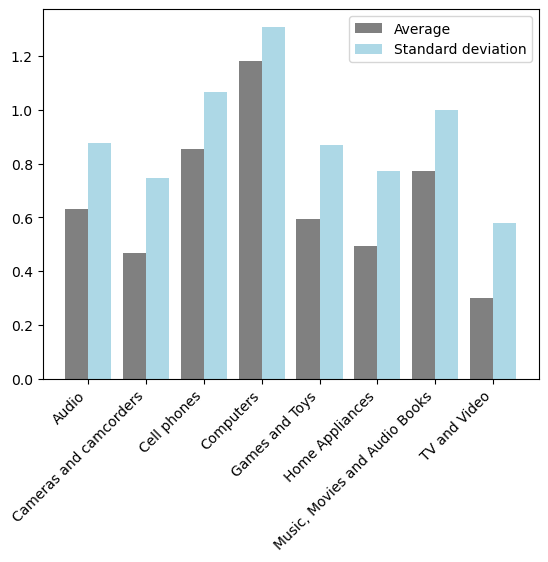

In [53]:
# Get the statistics
averages = cust_products.mean()
std = cust_products.std()
x_names = cust_products.columns
x_ix = np.arange(cust_products.shape[1])
# Plot the data
plt.bar(x_ix - 0.2, averages, color='grey', label='Average', width=0.4)
plt.bar(x_ix + 0.2, std, color='lightblue', label='Standard deviation', width=0.4)
plt.xticks(x_ix, x_names, rotation=45, ha='right')
plt.legend()
plt.show()

<b>Model assumptions</b>

1) K-Means clustering. Works well when data is 1) normally distributed (no skew) 2) standadized (mean=0, standard deviation=1) <br>
2) NMF. Can be used on raw data, especially if the matrix is sparse

Adding noise to small numbers in your dataset can help improve clustering by ensuring that small differences do not cause points to be considered identical. This can be especially useful in pairwise plots or clustering algorithms that might be sensitive to very close points.

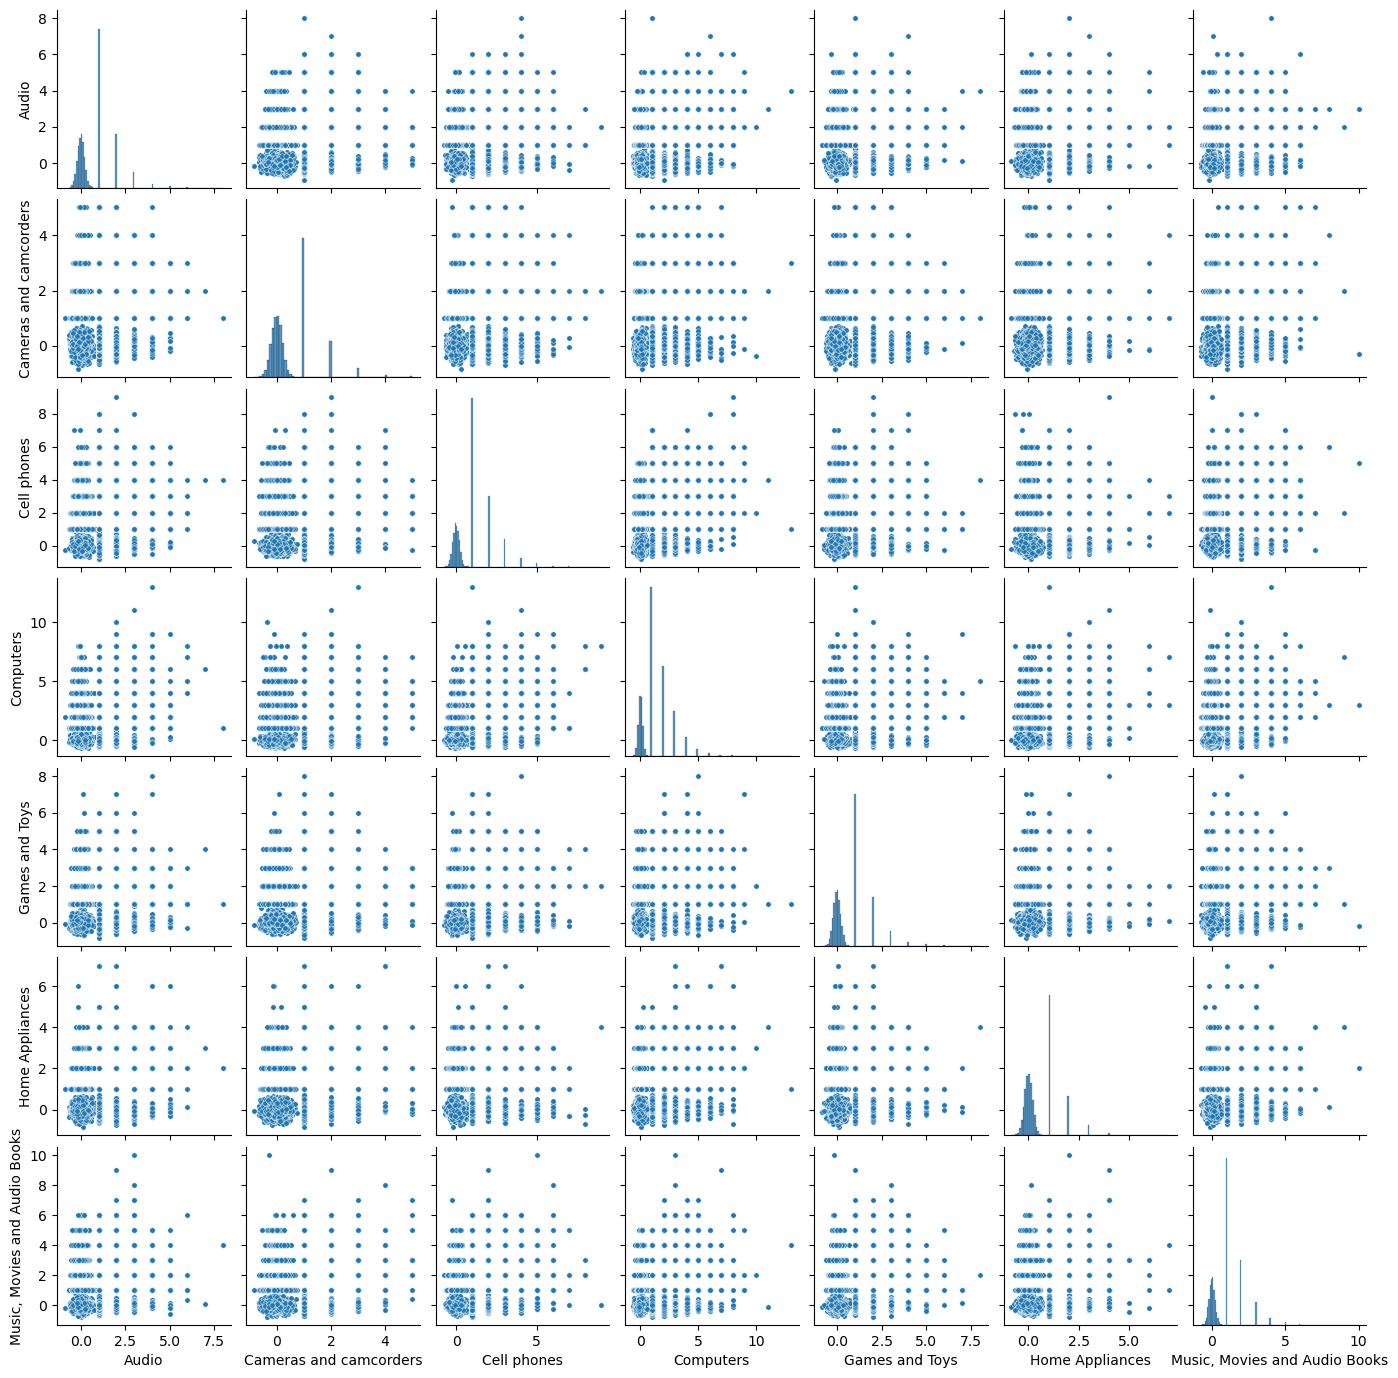

In [54]:
# Define a function to add noise to small numbers
def add_noise_to_small_numbers(df, threshold=0.1, noise_level=0.2):
    noisy_df = df.copy()
    noise = np.random.normal(loc=0, scale=noise_level, size=df.shape)
    noisy_df = df + noise * (df.abs() < threshold)
    return noisy_df

# Add noise to small numbers in the dataset
cust_products_noisy = add_noise_to_small_numbers(cust_products.iloc[:, :-1], threshold=0.1, noise_level=0.2)

# Create a pair plot with the noisy data to explore distributions 
pair_plot = sns.pairplot(cust_products_noisy, height=2, plot_kws={'s': 15})
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


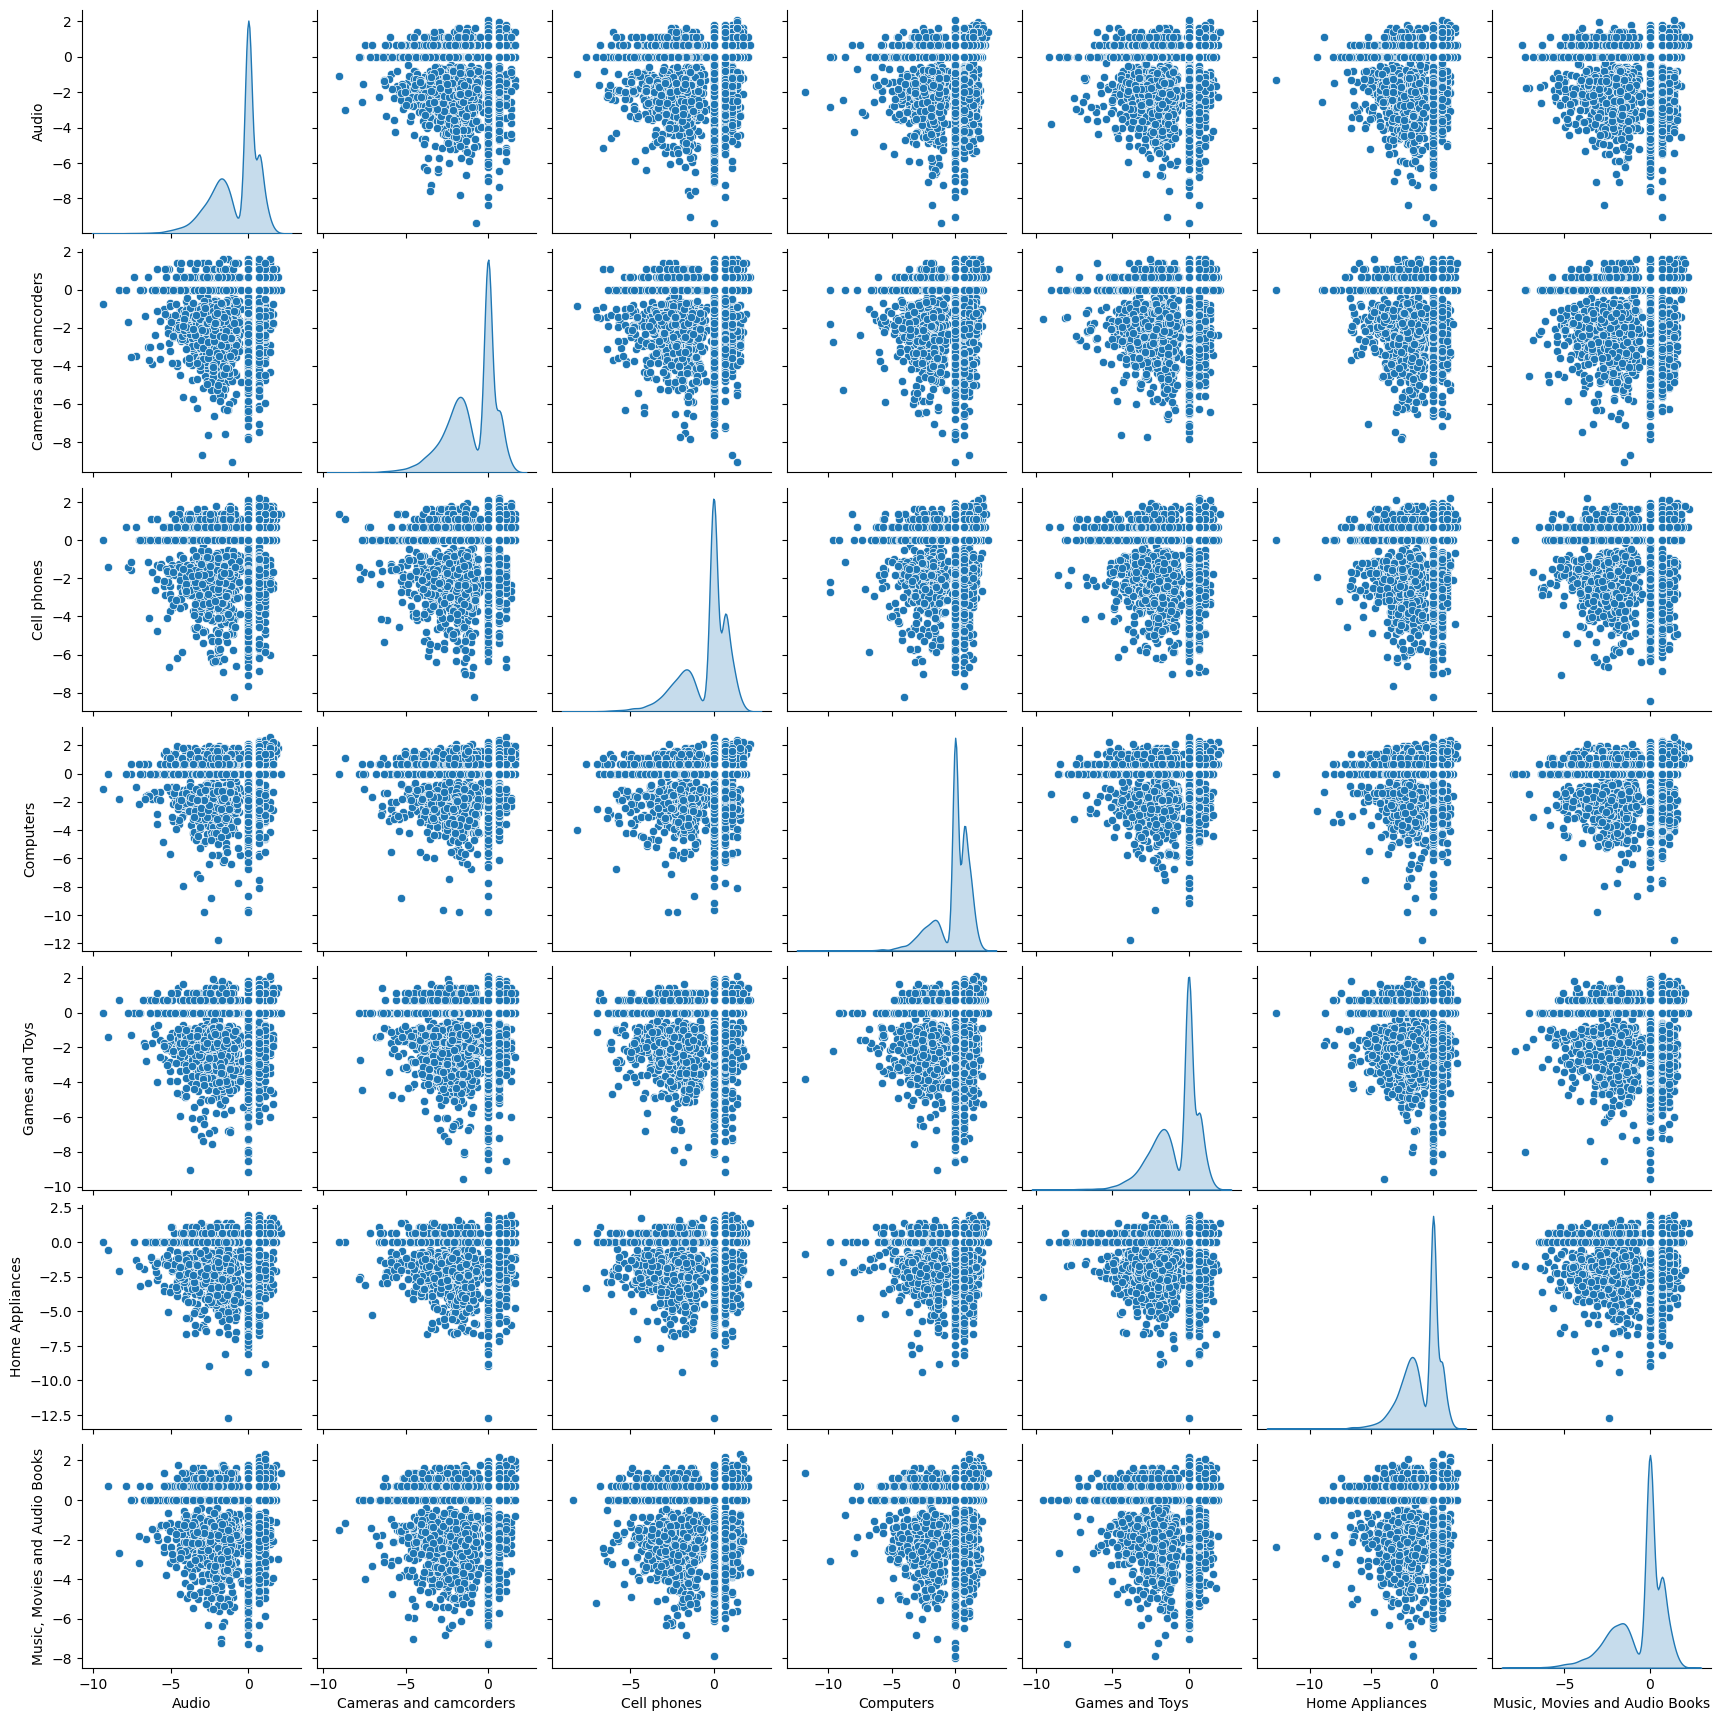

In [55]:
# first option, log transformation
cust_products_log = np.log(cust_products_noisy)
sns.pairplot(data=cust_products_log, diag_kind='kde') 
plt.show()

<b>Unskewing data with Box-Cox transformation</b>

In [56]:
# Second option - Box-Cox transformation
def boxcox_df(x):
    x_boxcox, _ = stats.boxcox(x)
    return x_boxcox
# since we have many zero values we add constant value 1 to the whole dataframe to make it suitable for boxcox transformation
cust_products_shifted = cust_products + 1
cust_products_boxcox = cust_products_shifted.apply(boxcox_df, axis=0)

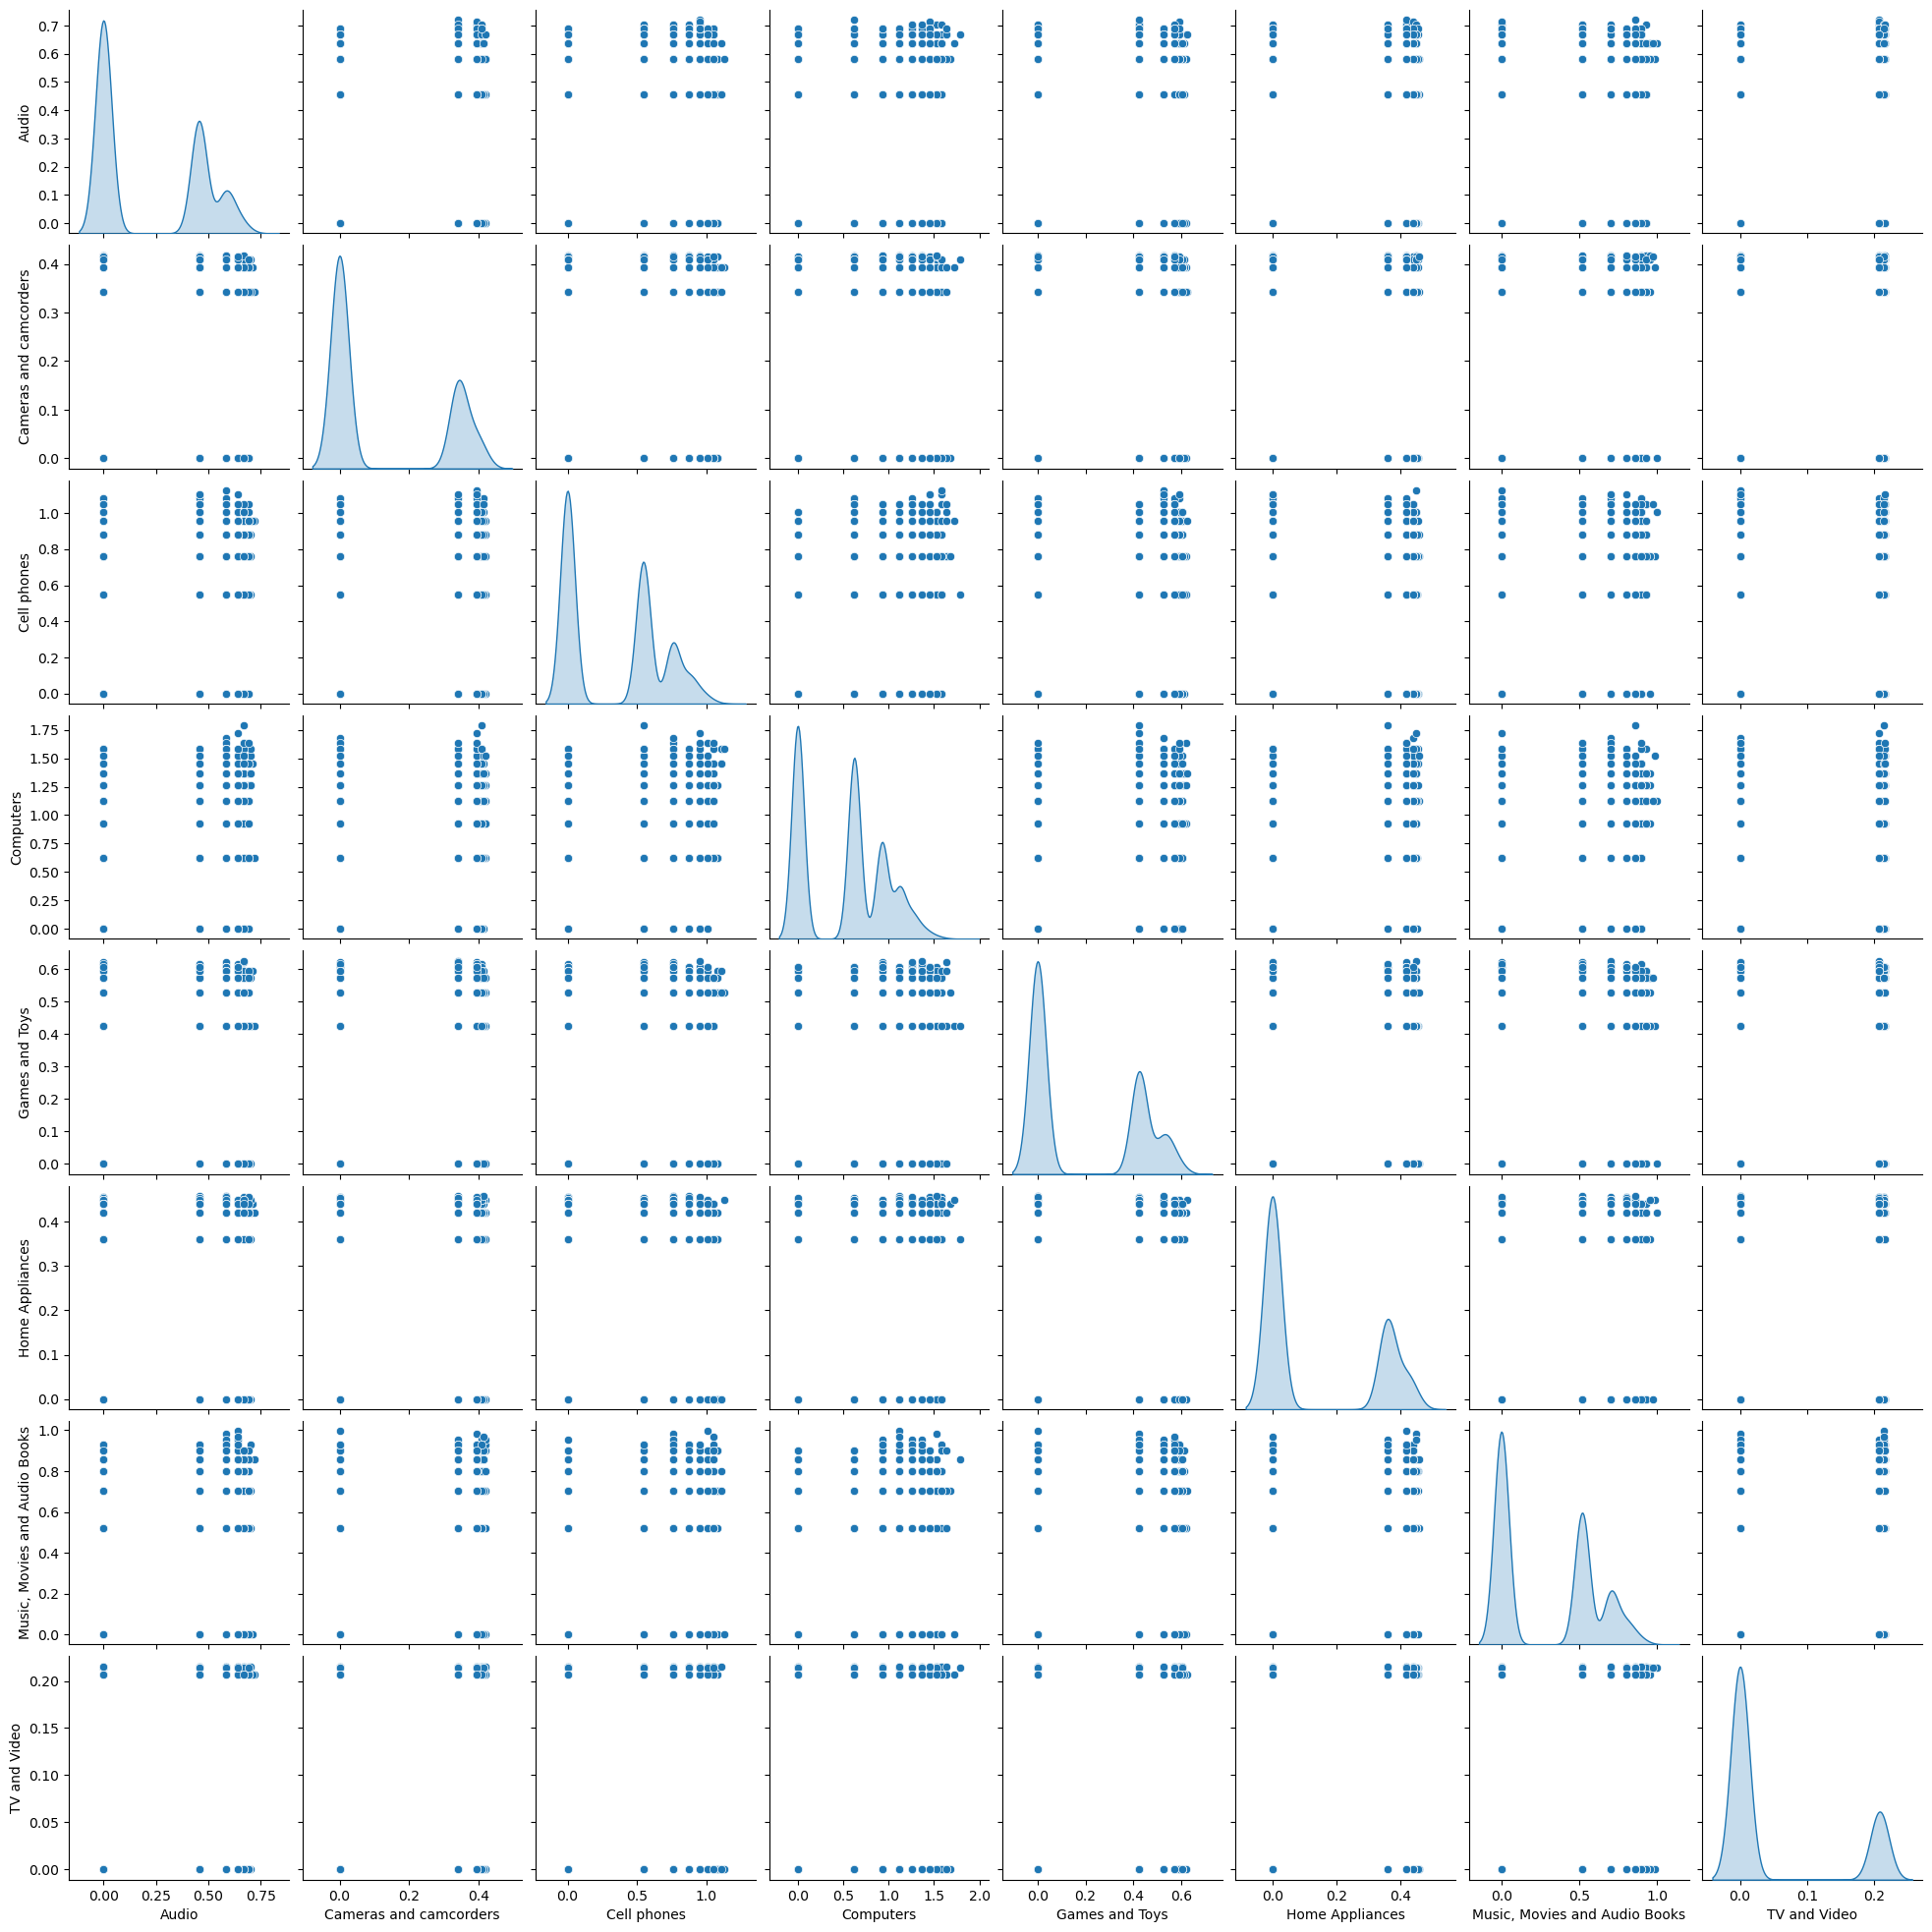

In [57]:
sns.pairplot(data=cust_products_boxcox, diag_kind='kde') 
plt.show()

<b>Scale the data</b>

Subtract column average from each column value; divie each column value by column standard deviation

In [58]:
scaler = StandardScaler()
scaler.fit(cust_products_boxcox)
cust_products_scaled = scaler.transform(cust_products_boxcox)
cust_products_scaled_df = pd.DataFrame(data=cust_products_scaled,
                                       index=cust_products_boxcox.index,
                                       columns=cust_products_boxcox.columns
                                      )
cust_products_scaled_df.agg(['mean', 'std']).round()

category,Audio,Cameras and camcorders,Cell phones,Computers,Games and Toys,Home Appliances,"Music, Movies and Audio Books",TV and Video
mean,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


<b>Segmentation</b>

In [59]:
# Explore elbow criterion method to define number of segments
# Iterate through a number of k values, then run clustering for each on the same data, then calculate sum of squared errors for each, then plot SSE against k and identify the elbow - diminishing incremental improvements in error reduction
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=99)
    kmeans.fit(cust_products_scaled_df)
    sse[k] = kmeans.inertia_

There is also test & learn method. We can calculate mathematically optimal number of segments. Then build segmentation with multiple values around the optimal k value. Explore results and choose one with most business relevance (segments should not be ambigous /overlapping)

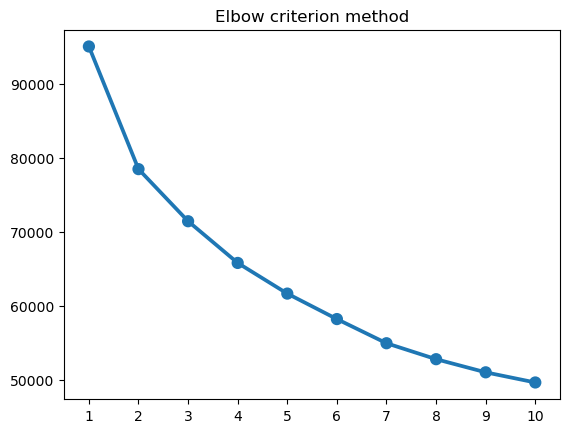

In [60]:
plt.title('Elbow criterion method')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

The elbow is around 2 clusters, which means we shoiuld start cluster with + 1 number of clusters, i.e. 3

<b>Segmentation steps with K-means</b>

In [61]:
# make a segmentation with K-Means(for k number of clusters)
kmeans = KMeans(n_clusters=3, random_state=99)
kmeans.fit(cust_products_scaled_df)
cust_products_kmeans3 = cust_products.assign(segment = kmeans.labels_)

<b>Segmentation steps with NMF</b>

In [62]:
# Segmentation with NMF
nmf = NMF(3)
nmf.fit(cust_products)
components = pd.DataFrame(nmf.components_, columns=cust_products.columns)
# Extracting segment assignment
segment_weights = pd.DataFrame(nmf.transform(cust_products), columns=components.index)
segment_weights.index = cust_products.index
cust_products_nmf3 = cust_products.assign(segment=segment_weights.idxmax(axis=1))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(


<b>Methods to explore segments</b>

Calculate average, media, other percentile values for each variable by segment; calculate relative importance for each variable by segment

<b>Analyze average K-means segmentation attributes</b>

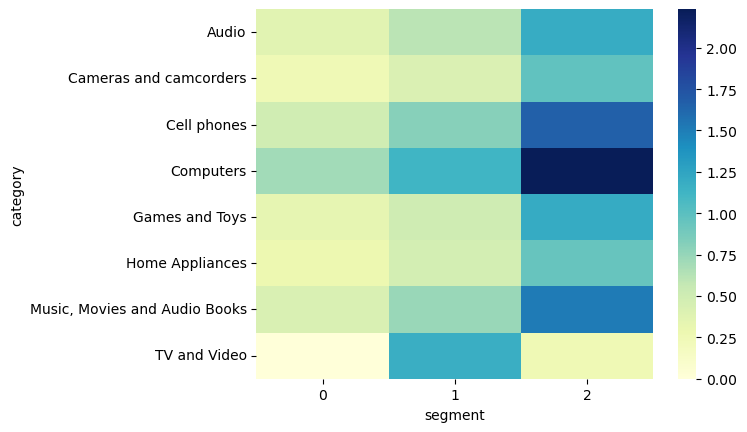

In [63]:
kmeans3_average = cust_products_kmeans3.groupby(['segment']).mean()
sns.heatmap(kmeans3_average.T, cmap='YlGnBu')
plt.show()

<b>Analyze average NMF segmentation attributes</b>

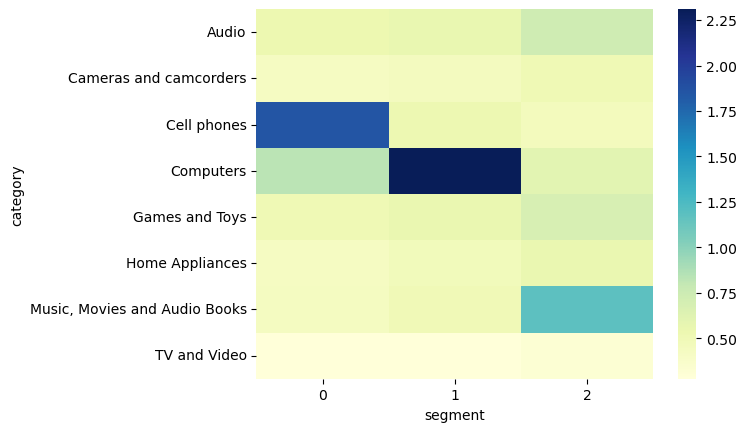

In [64]:
nmf3_average = cust_products_nmf3.groupby(['segment']).mean()
sns.heatmap(nmf3_average.T, cmap='YlGnBu')
plt.show()